# COMPAS experiments

This notebook runs the contextual bandit experiments on **COMPAS** for both sensitive attributes:

- `sex`
- `race_binary`

and for both preprocessing strategies:

- `uniform`
- `reweigh_group_label`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from fair_bandits.config import build_config
from fair_bandits.data import (
    load_compas,
    clean_compas_minimal,
    ensure_compas_race_binary,
    prepare_compas_contextual,
    make_group_label_sampling_probs,
)
from fair_bandits.policies import LinUCB, GroupAwareDPLinUCB
from fair_bandits.experiments import (
    run_multi_seed_bandit_experiment,
    summarize_over_seeds,
    compare_methods,
)
from fair_bandits.io import (
    export_experiment_bundle,
    experiment_bundle_exists,
    load_experiment_bundle,
)
from fair_bandits.plots import (
    plot_average_reward_over_time,
    plot_rolling_reward,
    plot_dp_gap_over_time,
    plot_benchmark_bars,
)


In [2]:
CFG = build_config("full")   # switch to "full" for thesis runs
DATASET_NAME = "COMPAS"

SENSITIVE_COLS = ["sex", "race_binary"]
PREPROCESSINGS = ["uniform", "reweigh_group_label"]

CFG

ExperimentConfig(run_mode='full', seed0=42, cache_dir=WindowsPath('data_cache'), results_dir=WindowsPath('results/full'), T_group_bandit=50000, T_contextual=30000, n_seeds=50, delta_fair=0.05, alpha_linucb=1.5, lambda_ridge=1.0, dp_tau=0.02, dp_lambda=2.0, beta_smooth=1.0, min_group_count=20, compas_hash_features=512, n_bootstrap=1000)

### Load and clean COMPAS

In [3]:
df = load_compas(cache_dir=CFG.cache_dir)
df = clean_compas_minimal(df)
df = ensure_compas_race_binary(df)

print("Shape after cleaning:", df.shape)
display(df.head())


Shape after cleaning: (7214, 10)


,sex,race,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,two_year_recid,race_binary
0,Male,Other,69,0,0,0,0,F,0,Non-White
1,Male,African-American,34,0,0,0,0,F,1,Non-White
2,Male,African-American,24,0,0,1,4,F,1,Non-White
3,Male,African-American,23,0,1,0,1,F,0,Non-White
4,Male,Other,43,0,0,0,2,F,0,Non-White


### Policy factories

In [4]:
def make_policy_factories(cfg):
    return {
        "LinUCB": lambda d, groups, seed: LinUCB(
            d=d,
            alpha=cfg.alpha_linucb,
            lam=cfg.lambda_ridge,
            n_actions=2,
        ),
        "GroupAwareDPLinUCB": lambda d, groups, seed: GroupAwareDPLinUCB(
            d=d,
            groups=groups,
            alpha=cfg.alpha_linucb,
            lam=cfg.lambda_ridge,
            tau=cfg.dp_tau,
            lambda_fair=cfg.dp_lambda,
            beta_smooth=cfg.beta_smooth,
            min_group_count=cfg.min_group_count,
            n_actions=2,
        ),
    }

policy_factories = make_policy_factories(CFG)
policy_factories.keys()


dict_keys(['LinUCB', 'GroupAwareDPLinUCB'])

### Run and load all experiment conditions

In [5]:
def run_or_load_compas_condition(
    *,
    df,
    sensitive_col: str,
    preprocessing: str,
    cfg,
    policy_factories,
):
    run_dir = (
        cfg.results_dir
        / DATASET_NAME.lower()
        / f"sensitive_{sensitive_col}"
        / preprocessing
    )
    run_dir.mkdir(parents=True, exist_ok=True)

    if experiment_bundle_exists(run_dir):
        bundle = load_experiment_bundle(run_dir)
        print(f"Loaded cached results: {run_dir}")
        return bundle, run_dir

    X, y, group, feature_names, meta = prepare_compas_contextual(
        df,
        sensitive_col=sensitive_col,
    )

    sampling_probs = None
    if preprocessing == "reweigh_group_label":
        sampling_probs = make_group_label_sampling_probs(group, y)

    bundle = run_multi_seed_bandit_experiment(
        X=X,
        y=y,
        group=group,
        policy_factories=policy_factories,
        horizon=cfg.T_contextual,
        n_seeds=cfg.n_seeds,
        seed0=cfg.seed0,
        sampling_probs=sampling_probs,
        replace=True,
        rolling_window=50,
        condition_cols={
            "dataset": DATASET_NAME,
            "sensitive": sensitive_col,
            "preprocessing": preprocessing,
        },
    )
    export_experiment_bundle(bundle, run_dir)
    print(f"Saved results: {run_dir}")
    return bundle, run_dir


bundles = {}
run_dirs = {}

for sensitive_col in SENSITIVE_COLS:
    for preprocessing in PREPROCESSINGS:
        key = (sensitive_col, preprocessing)
        bundle, run_dir = run_or_load_compas_condition(
            df=df,
            sensitive_col=sensitive_col,
            preprocessing=preprocessing,
            cfg=CFG,
            policy_factories=policy_factories,
        )
        bundles[key] = bundle
        run_dirs[key] = run_dir

print("Completed conditions:", list(bundles.keys()))


Saved results: results\full\compas\sensitive_sex\uniform
Saved results: results\full\compas\sensitive_sex\reweigh_group_label
Saved results: results\full\compas\sensitive_race_binary\uniform
Saved results: results\full\compas\sensitive_race_binary\reweigh_group_label
Completed conditions: [('sex', 'uniform'), ('sex', 'reweigh_group_label'), ('race_binary', 'uniform'), ('race_binary', 'reweigh_group_label')]


### Combine all seed summaries and logs

In [6]:
all_logs = pd.concat([bundle.logs for bundle in bundles.values()], ignore_index=True)
all_seed_summary = pd.concat([bundle.seed_summary for bundle in bundles.values()], ignore_index=True)
all_temporal_summary = pd.concat([bundle.temporal_summary for bundle in bundles.values()], ignore_index=True)

print("all_logs:", all_logs.shape)
print("all_seed_summary:", all_seed_summary.shape)
print("all_temporal_summary:", all_temporal_summary.shape)

display(all_seed_summary.head())


all_logs: (12000000, 16)
all_seed_summary: (400, 19)
all_temporal_summary: (240000, 18)


,dataset,sensitive,preprocessing,policy,seed,accuracy,DP_gap,TPR_gap,FPR_gap,EO_gap,PPV_gap,UtilityGap,CumulativeRegret,n_rounds,final_cum_reward,final_avg_reward,final_rolling_reward,final_dp_gap,final_cum_regret
0,COMPAS,sex,uniform,GroupAwareDPLinUCB,42,0.662967,0.087167,0.055816,0.046878,0.055816,0.095224,0.042965,10111.0,30000,19889.0,0.662967,0.74,0.087167,10111.0
1,COMPAS,sex,uniform,GroupAwareDPLinUCB,43,0.543033,0.005813,0.016307,0.014784,0.016307,0.107910,0.012935,13709.0,30000,16291.0,0.543033,0.48,0.005813,13709.0
2,COMPAS,sex,uniform,GroupAwareDPLinUCB,44,0.672633,0.066929,0.014858,0.048689,0.048689,0.082669,0.009659,9821.0,30000,20179.0,0.672633,0.60,0.066929,9821.0
3,COMPAS,sex,uniform,GroupAwareDPLinUCB,45,0.653133,0.061647,0.015806,0.051774,0.051774,0.081954,0.014095,10406.0,30000,19594.0,0.653133,0.66,0.061647,10406.0
4,COMPAS,sex,uniform,GroupAwareDPLinUCB,46,0.673267,0.073378,0.032788,0.033819,0.033819,0.093885,0.023985,9802.0,30000,20198.0,0.673267,0.72,0.073378,9802.0


### Aggregate summary tables

In [7]:
agg_summary = summarize_over_seeds(
    all_seed_summary,
    group_cols=["dataset", "sensitive", "preprocessing", "policy"],
)

display(agg_summary)


,dataset,sensitive,preprocessing,policy,n_seeds,accuracy_mean,accuracy_low,accuracy_high,DP_gap_mean,DP_gap_low,...,final_avg_reward_high,final_rolling_reward_mean,final_rolling_reward_low,final_rolling_reward_high,final_dp_gap_mean,final_dp_gap_low,final_dp_gap_high,final_cum_regret_mean,final_cum_regret_low,final_cum_regret_high
0,COMPAS,race_binary,reweigh_group_label,GroupAwareDPLinUCB,50,0.637356,0.583331,0.661488,0.026810,0.002700,...,0.661488,0.6488,0.4845,0.7955,0.026810,0.002700,0.062182,10879.32,10155.375,12500.075
1,COMPAS,race_binary,reweigh_group_label,LinUCB,50,0.639729,0.586658,0.661306,0.040923,0.001242,...,0.661306,0.6440,0.5400,0.7600,0.040923,0.001242,0.117713,10808.12,10160.825,12400.250
2,COMPAS,race_binary,uniform,GroupAwareDPLinUCB,50,0.649083,0.563191,0.677665,0.088380,0.059922,...,0.677665,0.6532,0.5245,0.7600,0.088380,0.059922,0.120238,10527.52,9670.050,13104.275
3,COMPAS,race_binary,uniform,LinUCB,50,0.651299,0.564151,0.678191,0.185943,0.080734,...,0.678191,0.6576,0.5045,0.7600,0.185943,0.080734,0.361991,10461.02,9654.275,13075.475
4,COMPAS,sex,reweigh_group_label,GroupAwareDPLinUCB,50,0.630315,0.543284,0.664666,0.049682,0.009031,...,0.664666,0.6344,0.4445,0.8000,0.049682,0.009031,0.065119,11090.56,10060.025,13701.475
5,COMPAS,sex,reweigh_group_label,LinUCB,50,0.629954,0.543179,0.665003,0.075677,0.021631,...,0.665003,0.6304,0.4400,0.7910,0.075677,0.021631,0.106554,11101.38,10049.925,13704.625
6,COMPAS,sex,uniform,GroupAwareDPLinUCB,50,0.644003,0.548903,0.673169,0.067031,0.030314,...,0.673169,0.6552,0.4800,0.7600,0.067031,0.030314,0.090428,10679.92,9804.925,13532.900
7,COMPAS,sex,uniform,LinUCB,50,0.638259,0.543704,0.676897,0.108180,0.024076,...,0.676897,0.6492,0.4890,0.7600,0.108180,0.024076,0.139000,10852.22,9693.100,13688.875


In [8]:
main_table_cols = [
    "dataset",
    "sensitive",
    "preprocessing",
    "policy",
    "accuracy_mean",
    "DP_gap_mean",
    "TPR_gap_mean",
    "EO_gap_mean",
    "PPV_gap_mean",
    "UtilityGap_mean",
    "CumulativeRegret_mean",
]

main_table = agg_summary[main_table_cols].sort_values(
    ["sensitive", "preprocessing", "policy"]
).reset_index(drop=True)

display(main_table)


,dataset,sensitive,preprocessing,policy,accuracy_mean,DP_gap_mean,TPR_gap_mean,EO_gap_mean,PPV_gap_mean,UtilityGap_mean,CumulativeRegret_mean
0,COMPAS,race_binary,reweigh_group_label,GroupAwareDPLinUCB,0.637356,0.026810,0.040089,0.052339,0.024610,0.025639,10879.32
1,COMPAS,race_binary,reweigh_group_label,LinUCB,0.639729,0.040923,0.052351,0.066781,0.025652,0.025621,10808.12
2,COMPAS,race_binary,uniform,GroupAwareDPLinUCB,0.649083,0.088380,0.041507,0.100692,0.046468,0.016833,10527.52
3,COMPAS,race_binary,uniform,LinUCB,0.651299,0.185943,0.122299,0.219591,0.021413,0.013063,10461.02
4,COMPAS,sex,reweigh_group_label,GroupAwareDPLinUCB,0.630315,0.049682,0.045613,0.064065,0.022693,0.014751,11090.56
5,COMPAS,sex,reweigh_group_label,LinUCB,0.629954,0.075677,0.073946,0.090517,0.028829,0.015015,11101.38
6,COMPAS,sex,uniform,GroupAwareDPLinUCB,0.644003,0.067031,0.026796,0.059005,0.085804,0.027092,10679.92
7,COMPAS,sex,uniform,LinUCB,0.638259,0.108180,0.063363,0.112169,0.073474,0.031990,10852.22


### Figures

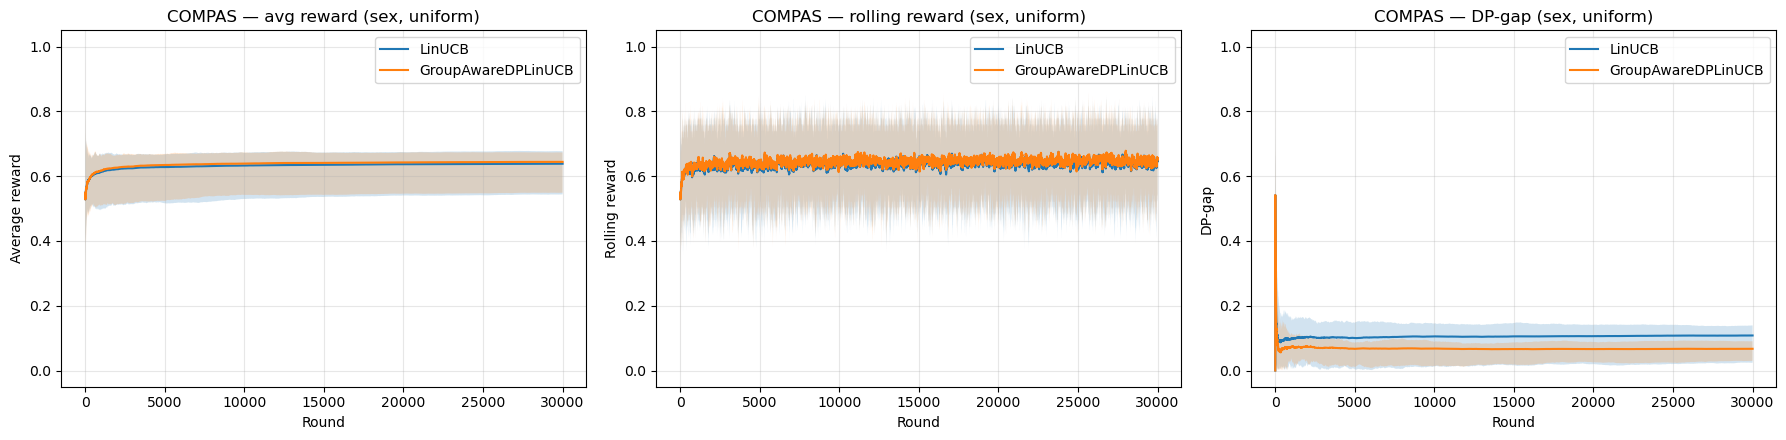

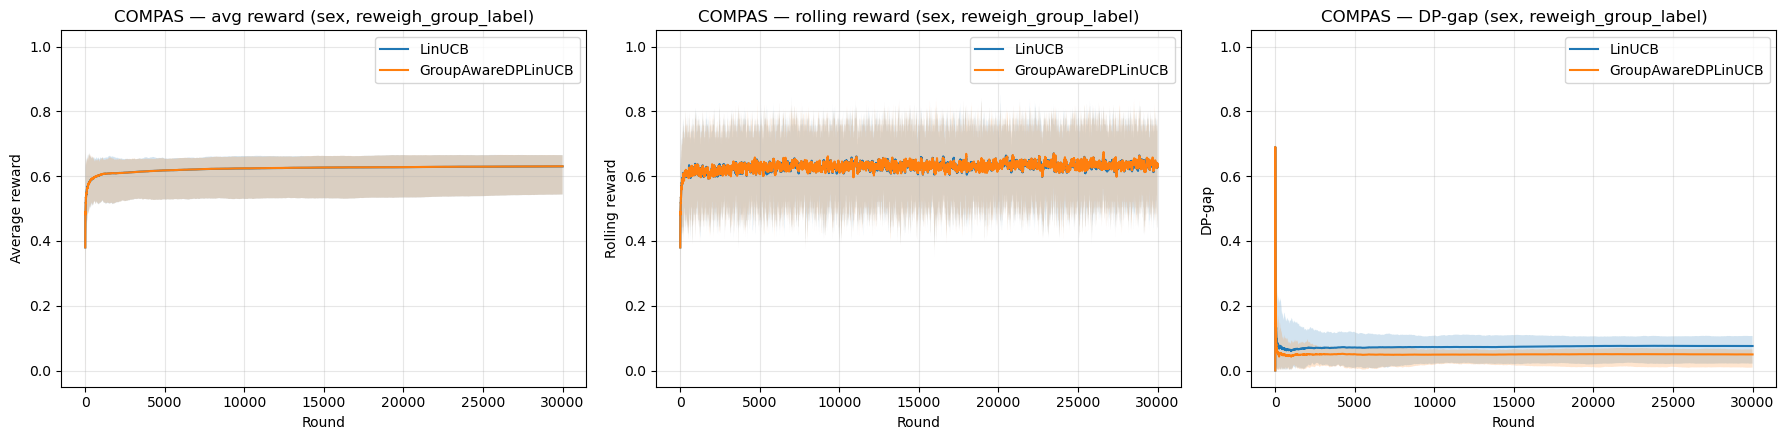

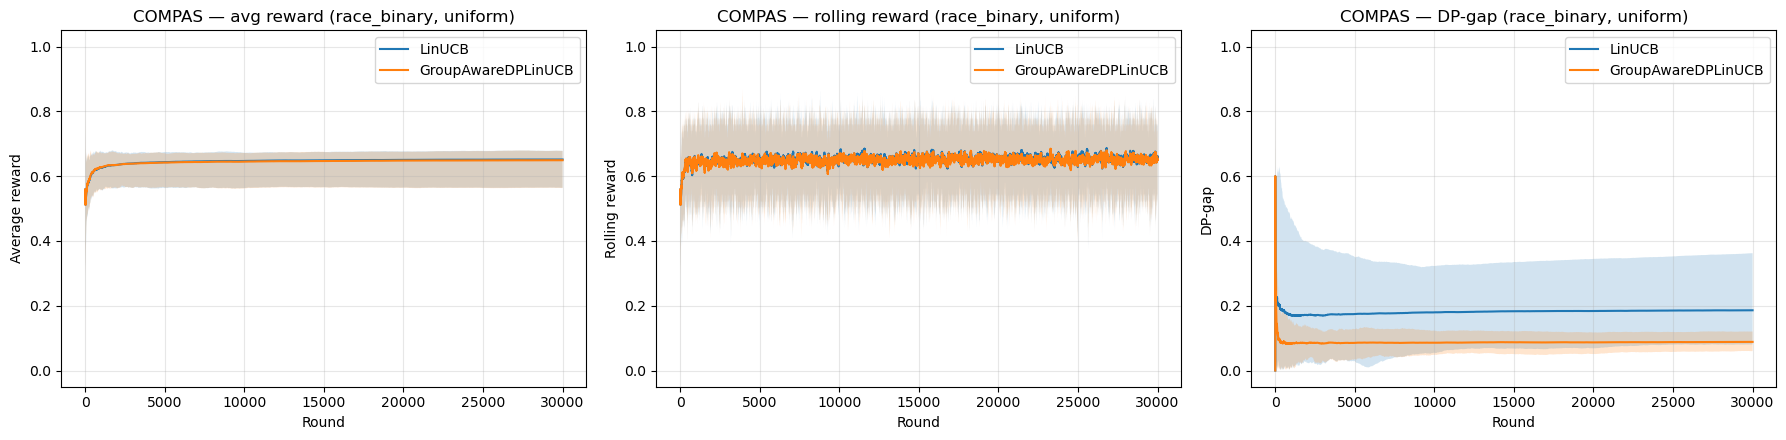

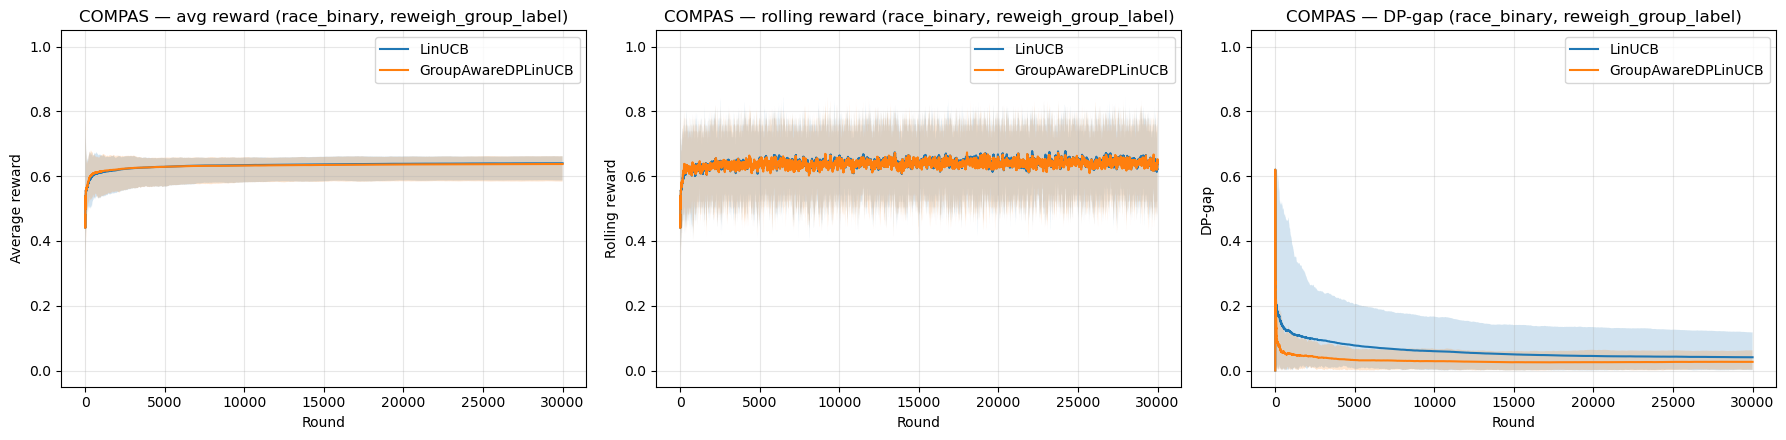

In [9]:
for sensitive_col in SENSITIVE_COLS:
    for preprocessing in PREPROCESSINGS:
        filters = {
            "dataset": DATASET_NAME,
            "sensitive": sensitive_col,
            "preprocessing": preprocessing,
        }

        fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

        plot_average_reward_over_time(
            all_logs,
            filters=filters,
            policy_order=["LinUCB", "GroupAwareDPLinUCB"],
            ax=axes[0],
            title=f"{DATASET_NAME} — avg reward ({sensitive_col}, {preprocessing})",
        )
        plot_rolling_reward(
            all_logs,
            filters=filters,
            policy_order=["LinUCB", "GroupAwareDPLinUCB"],
            ax=axes[1],
            title=f"{DATASET_NAME} — rolling reward ({sensitive_col}, {preprocessing})",
        )
        plot_dp_gap_over_time(
            all_logs,
            filters=filters,
            policy_order=["LinUCB", "GroupAwareDPLinUCB"],
            ax=axes[2],
            title=f"{DATASET_NAME} — DP-gap ({sensitive_col}, {preprocessing})",
        )

        plt.tight_layout()
        plt.show()


### Benchmark bars

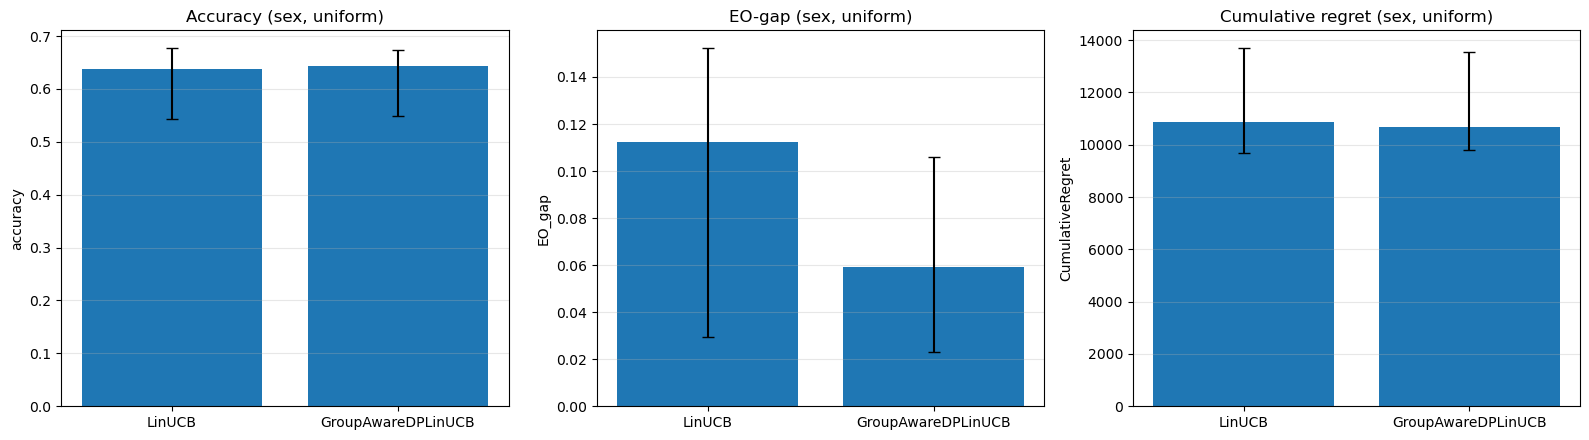

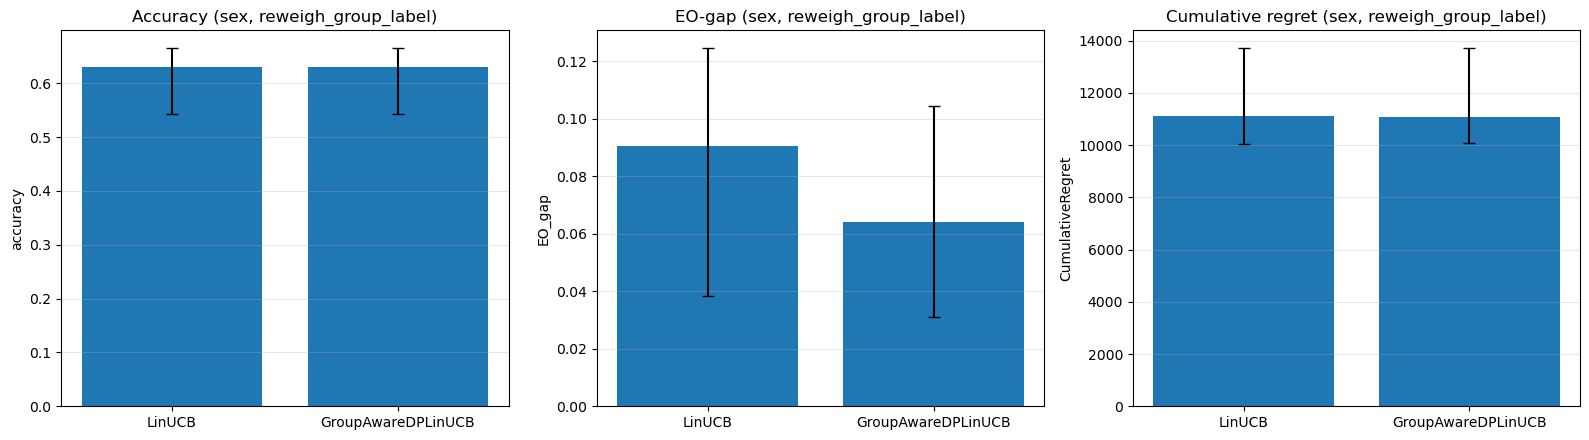

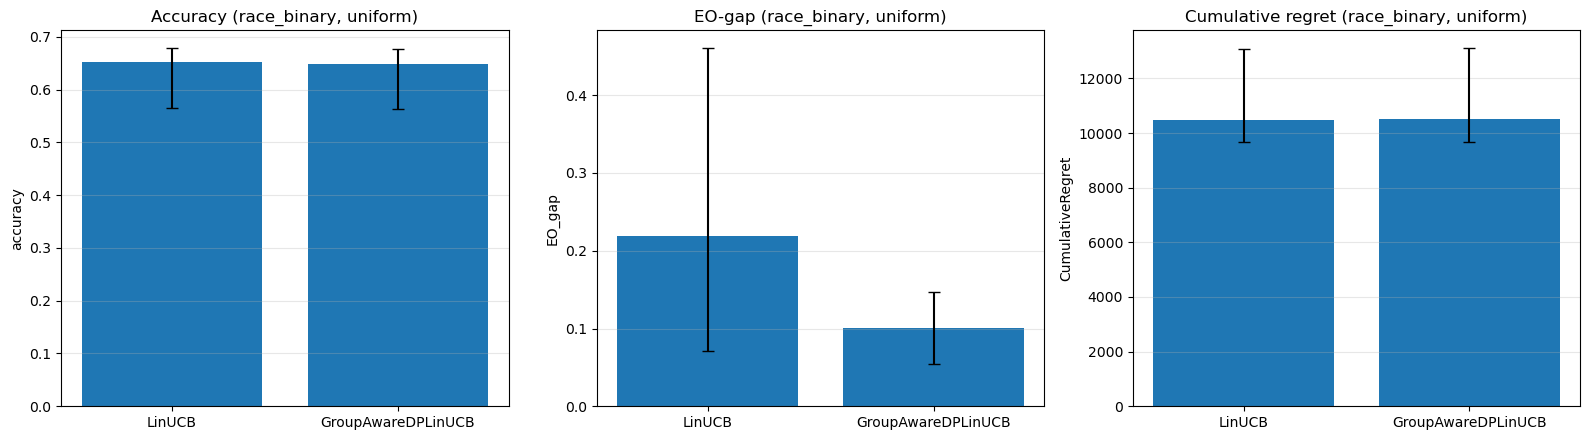

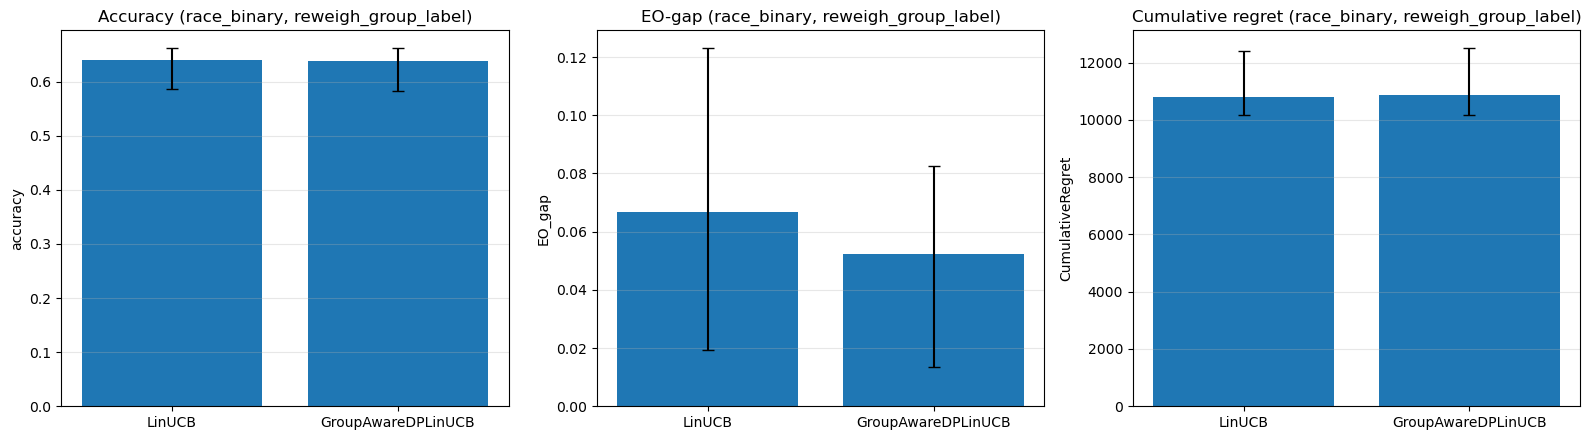

In [10]:
for sensitive_col in SENSITIVE_COLS:
    for preprocessing in PREPROCESSINGS:
        filters = {
            "dataset": DATASET_NAME,
            "sensitive": sensitive_col,
            "preprocessing": preprocessing,
        }

        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

        plot_benchmark_bars(
            all_seed_summary,
            metric="accuracy",
            filters=filters,
            policy_order=["LinUCB", "GroupAwareDPLinUCB"],
            ax=axes[0],
            title=f"Accuracy ({sensitive_col}, {preprocessing})",
        )
        plot_benchmark_bars(
            all_seed_summary,
            metric="EO_gap",
            filters=filters,
            policy_order=["LinUCB", "GroupAwareDPLinUCB"],
            ax=axes[1],
            title=f"EO-gap ({sensitive_col}, {preprocessing})",
        )
        plot_benchmark_bars(
            all_seed_summary,
            metric="CumulativeRegret",
            filters=filters,
            policy_order=["LinUCB", "GroupAwareDPLinUCB"],
            ax=axes[2],
            title=f"Cumulative regret ({sensitive_col}, {preprocessing})",
        )

        plt.tight_layout()
        plt.show()


### Statistics

We run paired comparisons across seeds for the main fairness and utility metrics.


In [11]:
metrics_to_test = {
    "accuracy": False,
    "DP_gap": True,
    "EO_gap": True,
    "PPV_gap": True,
    "CumulativeRegret": True,
}

friedman_results = {}
wilcoxon_results = {}

for metric_name, lower_is_better in metrics_to_test.items():
    friedman_df, wilcoxon_df = compare_methods(
        all_seed_summary,
        value_col=metric_name,
        method_col="policy",
        seed_col="seed",
        group_cols=["dataset", "sensitive", "preprocessing"],
        lower_is_better=lower_is_better,
    )
    friedman_results[metric_name] = friedman_df
    wilcoxon_results[metric_name] = wilcoxon_df

    print(f"\n=== {metric_name} ===")
    display(friedman_df)
    display(wilcoxon_df)



=== accuracy ===


""


,dataset,sensitive,preprocessing,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,COMPAS,race_binary,reweigh_group_label,accuracy,GroupAwareDPLinUCB,LinUCB,50,0.637356,0.639729,-0.002373,560.5,0.457259,LinUCB,0.457259
1,COMPAS,race_binary,uniform,accuracy,GroupAwareDPLinUCB,LinUCB,50,0.649083,0.651299,-0.002217,420.0,0.035391,LinUCB,0.035391
2,COMPAS,sex,reweigh_group_label,accuracy,GroupAwareDPLinUCB,LinUCB,50,0.630315,0.629954,0.000361,487.0,0.415139,GroupAwareDPLinUCB,0.415139
3,COMPAS,sex,uniform,accuracy,GroupAwareDPLinUCB,LinUCB,50,0.644003,0.638259,0.005743,530.5,0.301642,GroupAwareDPLinUCB,0.301642



=== DP_gap ===


""


...

""


,dataset,sensitive,preprocessing,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,COMPAS,race_binary,reweigh_group_label,PPV_gap,GroupAwareDPLinUCB,LinUCB,50,0.024610,0.025652,-0.001042,558.0,4.490068e-01,GroupAwareDPLinUCB,4.490068e-01
1,COMPAS,race_binary,uniform,PPV_gap,GroupAwareDPLinUCB,LinUCB,50,0.046468,0.021413,0.025055,5.0,1.776357e-14,LinUCB,1.776357e-14
2,COMPAS,sex,reweigh_group_label,PPV_gap,GroupAwareDPLinUCB,LinUCB,50,0.022693,0.028829,-0.006136,119.0,9.154669e-07,GroupAwareDPLinUCB,9.154669e-07
3,COMPAS,sex,uniform,PPV_gap,GroupAwareDPLinUCB,LinUCB,50,0.085804,0.073474,0.012330,12.0,1.243450e-13,LinUCB,1.243450e-13



=== CumulativeRegret ===


""


,dataset,sensitive,preprocessing,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,COMPAS,race_binary,reweigh_group_label,CumulativeRegret,GroupAwareDPLinUCB,LinUCB,50,10879.32,10808.12,71.20,561.0,0.460168,LinUCB,0.460168
1,COMPAS,race_binary,uniform,CumulativeRegret,GroupAwareDPLinUCB,LinUCB,50,10527.52,10461.02,66.50,419.5,0.035340,LinUCB,0.035340
2,COMPAS,sex,reweigh_group_label,CumulativeRegret,GroupAwareDPLinUCB,LinUCB,50,11090.56,11101.38,-10.82,487.0,0.415126,GroupAwareDPLinUCB,0.415126
3,COMPAS,sex,uniform,CumulativeRegret,GroupAwareDPLinUCB,LinUCB,50,10679.92,10852.22,-172.30,531.0,0.303904,GroupAwareDPLinUCB,0.303904


### Export aggregated tables

In [12]:
summary_dir = CFG.results_dir / DATASET_NAME.lower() / "combined_summary"
summary_dir.mkdir(parents=True, exist_ok=True)

agg_summary.to_csv(summary_dir / "agg_summary.csv", index=False)
main_table.to_csv(summary_dir / "main_table.csv", index=False)

for metric_name, friedman_df in friedman_results.items():
    friedman_df.to_csv(summary_dir / f"friedman_{metric_name}.csv", index=False)

for metric_name, wilcoxon_df in wilcoxon_results.items():
    wilcoxon_df.to_csv(summary_dir / f"wilcoxon_{metric_name}.csv", index=False)

print("Exported summary files to:", summary_dir)


Exported summary files to: results\full\compas\combined_summary
